# Differential Privacy Assignment

# <span style="color:blue"> Introduction</span>

In this assignment, you will extend the concepts demonstrated in the lab portion to analyze income levels within a specific ethnic group: Native Americans. The goal is to understand how applying differential privacy impacts our analysis when focusing on a smaller, often underrepresented population group.

Specifically, you will explore how the Laplace mechanism affects the <b>income level counts</b> for Native Americans. Education and other government funding often depend on accurate data about income levels, and differential privacy can introduce noise that may distort these figures. Your task will be to determine how varying the privacy budget (epsilon) changes the accuracy of these counts and to reflect on the broader implications of these changes, particularly when allocating resources to underrepresented groups.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure inline plotting for Jupyter Notebook
%matplotlib inline

In [3]:
# Set random seed for reproducibility
np.random.seed(531)

# Define population size
population_size = 10000

# Define ethnicity categories and corresponding proportions (mock American demographics)
ethnicities = ['White', 'Hispanic', 'Black', 'Asian', 'Native American', 'Other']
proportions_ethnicity = [0.60, 0.18, 0.12, 0.06, 0.01, 0.03]

# Define age groups and proportions (mock age distribution)
age_groups = ['0-18', '19-35', '36-60', '60+']
age_proportions = [0.25, 0.35, 0.25, 0.15]

# Define income levels and corresponding proportions
income_levels = ['Low', 'Middle', 'High']
income_proportions = [0.40, 0.40, 0.20]

# Define urban vs rural distribution
locations = ['Urban', 'Rural']
location_proportions = [0.70, 0.30]

# Define education levels and their proportions
education_levels = ['No High School', 'High School', 'College', 'Graduate']
education_proportions = [0.15, 0.35, 0.35, 0.15]

# Generate the dataset using random choices from the defined proportions
df = pd.DataFrame({
    'Ethnicity': np.random.choice(ethnicities, size=population_size, p=proportions_ethnicity),
    'Age': np.random.choice(age_groups, size=population_size, p=age_proportions),
    'Income': np.random.choice(income_levels, size=population_size, p=income_proportions),
    'Location': np.random.choice(locations, size=population_size, p=location_proportions),
    'Education': np.random.choice(education_levels, size=population_size, p=education_proportions)
})

# Display the first 10 rows
print("Sample of Mock Dataset:")
print(df.head(10))

# Calculate and display frequency count for all ethnicities
ethnicity_counts = df['Ethnicity'].value_counts()
print("\nFrequency count for all ethnicities in the original dataset:")
print(ethnicity_counts)

Sample of Mock Dataset:
  Ethnicity    Age  Income Location    Education
0  Hispanic  19-35  Middle    Urban      College
1     White  19-35  Middle    Urban      College
2     Asian  36-60  Middle    Urban  High School
3  Hispanic  19-35  Middle    Urban  High School
4     Other  36-60     Low    Urban     Graduate
5     White  36-60     Low    Urban      College
6     White  36-60  Middle    Urban  High School
7     White   0-18  Middle    Urban     Graduate
8     White    60+     Low    Urban      College
9     White  36-60  Middle    Urban  High School

Frequency count for all ethnicities in the original dataset:
Ethnicity
White              5991
Hispanic           1780
Black              1217
Asian               594
Other               307
Native American     111
Name: count, dtype: int64


## Step 1: Calculate Original Counts for Income Levels


In [4]:
# Filter dataset for Native American subgroup
native_american_data = df[df['Ethnicity'] == 'Native American']

# Get original income counts for Native Americans
income_counts_native_american = native_american_data['Income'].value_counts()

# Display original income counts (Low, MIddle, & High) for Native Americans
print("\nIncome Level Counts for Native Americans (Original Data):")
for income_level, count in income_counts_native_american.items():
    print(f"{income_level}: {count}")



Income Level Counts for Native Americans (Original Data):
Low: 45
Middle: 39
High: 27


## <span style="color:blue">Step 2:</span> Apply Laplace Mechanism to Add Noise, Try (at least) Two Different Epsilon Values

<span style="color:blue">Instructions:</span>

<b>1. Apply Laplace Mechanism to Add Noise:</b>
Use the apply_laplace_mechanism function from the lab to add noise to the income level counts of the Native American subgroup.
Calculate the noisy counts for each of the income levels (Low, Middle, High) and observe how the Laplace mechanism affects these counts.

<b>2. Try at Least Two Different Epsilon Values:</b>
Select at least two different values for epsilon (e.g., epsilon = 0.1 and epsilon = 1.0).
Epsilon is a privacy budget parameter. A smaller epsilon value provides stronger privacy guarantees but more noise, whereas a larger epsilon value provides weaker privacy guarantees but more accuracy.
For each epsilon value, add Laplace noise to the income level counts and record the noisy counts.

<b>3. Analyze the Impact of Noise:</b>
Calculate the percent relative error for each income level for each epsilon value.
Reflect on the effects of the noise injected for each epsilon value in the "Observation and Reflection" section. How does changing epsilon affect the representation and accuracy of the income level counts for the Native American subgroup?

In [6]:
np.random.seed(531)

# Define Laplace mechanism function to add differential privacy noise to counts
def apply_laplace_mechanism(counts, epsilon, sensitivity=1):
    noisy_counts = {}
    for key, value in counts.items(): # Changed .item() to .items()
      noise = np.random.laplace(loc=0, scale=sensitivity / epsilon)
      noisy_counts[key] = max(0, value + noise)
    return noisy_counts

# Set privacy budget to inject noise
epsilon_values = [0.1, 0.6]  # <--Choose two different epsilon values

# Define a function to calculate percent relative error (if you are interested!)
def pct_error(orig, priv):
  if orig == 0:
    return 0
  return (priv - orig) /orig * 100.0

# Calculate and print change in representation for each income level for each epsilon value
for epsilon in epsilon_values:
  noisy_counts_native_american = apply_laplace_mechanism(income_counts_native_american.to_dict(), epsilon)

  print(f"\n Change in Representation with Epsilon = {epsilon}:")
  # Iterate over income levels, not ethnicities
  for income_level_key in income_counts_native_american.index:
        original_count = income_counts_native_american[income_level_key]
        noisy_count = noisy_counts_native_american[income_level_key]

        # Calculate change in representation
        if original_count > 0:
            change_in_representation = (noisy_count - original_count) / original_count * 100
        else:
            change_in_representation = 0

        # Print
        print(f"Income Level: {income_level_key}") # Used income_level_key
        print(f" - Original Count: {original_count}")
        print(f" - Noisy Count: {noisy_count:.2f}") # Added formatting for noisy_count
        print(f" - Change in Representation (%): {change_in_representation:.2f}%\n")



 Change in Representation with Epsilon = 0.1:
Income Level: Low
 - Original Count: 45
 - Noisy Count: 49.77
 - Change in Representation (%): 10.61%

Income Level: Middle
 - Original Count: 39
 - Noisy Count: 35.57
 - Change in Representation (%): -8.79%

Income Level: High
 - Original Count: 27
 - Noisy Count: 50.01
 - Change in Representation (%): 85.24%


 Change in Representation with Epsilon = 0.6:
Income Level: Low
 - Original Count: 45
 - Noisy Count: 45.56
 - Change in Representation (%): 1.25%

Income Level: Middle
 - Original Count: 39
 - Noisy Count: 44.33
 - Change in Representation (%): 13.68%

Income Level: High
 - Original Count: 27
 - Noisy Count: 25.41
 - Change in Representation (%): -5.90%



**Analysis:**

**With epsilon 0.1**
 - very strong privacy
 - The high income level has 85% distortion. This could be due to original count is 27 and Noise magnitue is large.

**With epsilon 0.6**
- Moderate privacy
- Changes are mush more stable.
- No Extreme distorin

## <span style="color:blue">Step 3:</span> Generate Relative Error Histogram Visualization for Native Americans

<span style="color:blue">Instructions:</span>

Create histograms to visualize the distribution of relative errors for the income level counts of Native Americans for each value of epsilon.

<b>1.Generate 1000 differentially private samples</b> of income level counts and calculate the relative error for each one.

<b>2.Label your visualizations</b> to clearly indicate the epsilon value used.


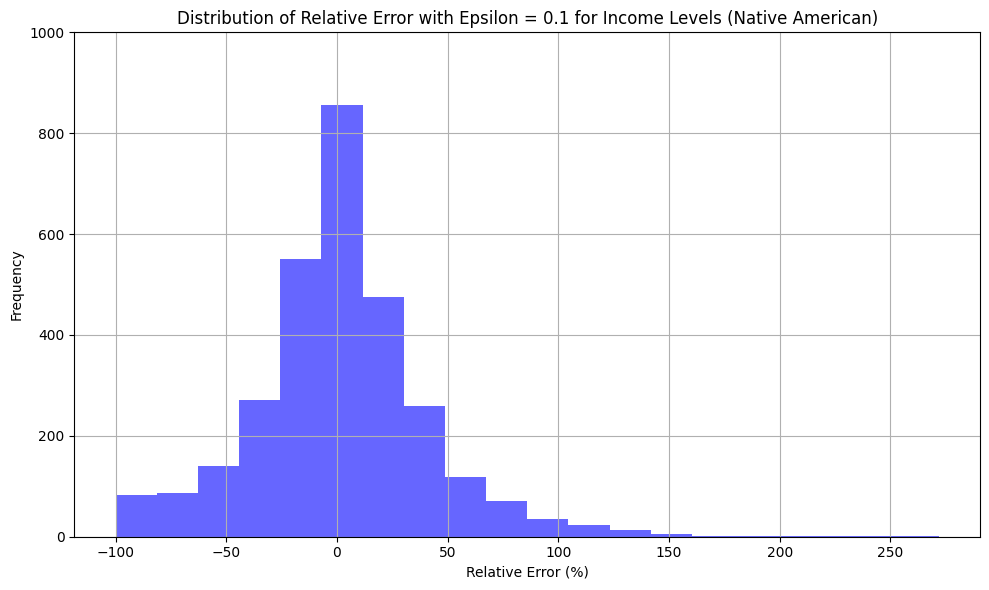

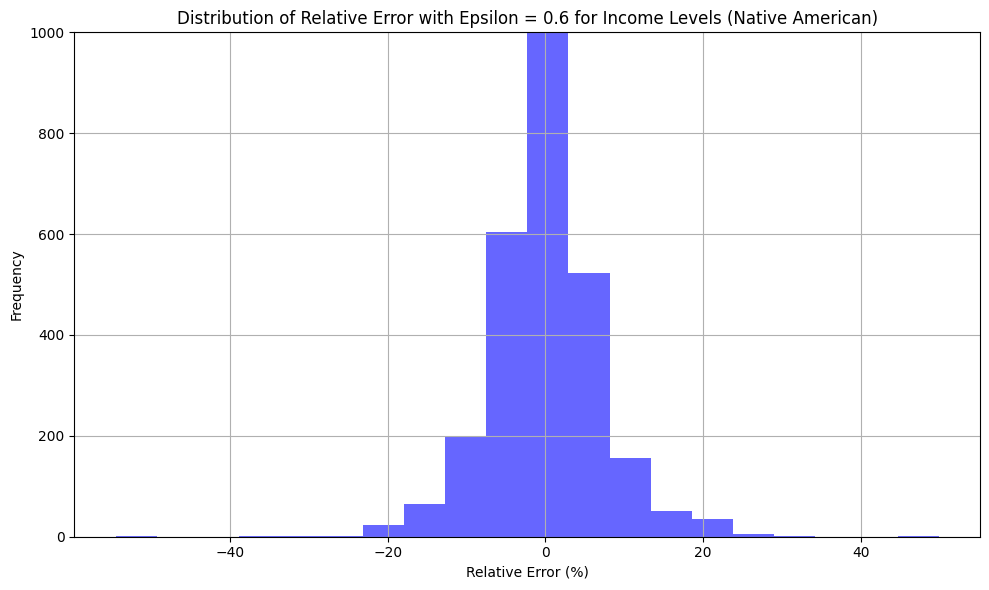

In [7]:
# Visualize the distribution of relative errors using histogram
def graph_relative_error_histogram(original_counts, epsilon_values, num_samples=1000):
    for epsilon in epsilon_values:
        relative_errors = []

        # Generate differentially private answers and calculate relative errors
        for _ in range(num_samples):
            noisy_counts = apply_laplace_mechanism(original_counts.to_dict(), epsilon)
            for income_level_key in original_counts.index:
              original_count = original_counts[income_level_key]
              noisy_count = noisy_counts[income_level_key]

              # Calculate relative error
              relative_error = pct_error(original_count, noisy_count)
              relative_errors.append(relative_error)

        # Plot histogram of relative errors
        plt.figure(figsize=(10, 6))
        plt.hist(relative_errors, bins=20, alpha=0.6, color='blue')
        plt.xlabel('Relative Error (%)')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of Relative Error with Epsilon = {epsilon} for Income Levels (Native American)')
        plt.grid(True)
        plt.ylim(0, 1000)
        plt.tight_layout()
        plt.show()

# Visualize the relative error for the income counts with different epsilon values
graph_relative_error_histogram(income_counts_native_american, epsilon_values)

## <span style="color:blue">Step 4: </span>Observation and Reflection


1. <b>Briefly describe your findings. How does changing the value of epsilon affect the relative error?</b>

2. <b>Is there an epsilon value that produces results useful while still providing privacy protection? Explain your reasoning.</b>

3. <b>Discuss how the trade-offs between privacy and data utility in differential privacy might impact smaller communities in a dataset. How might the added noise impact decision-making, especially in the context of census data?</b>